# Modelos Matemáticos para la ciencia de datos
## Práctica: Regresiones lineales simples

En esta práctica, analizaremos los datos del concurso [Kaggle: House Prices - Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques). Para enfocarnos en implementar una regresión lineal, se te ha proporcionado una hoja de cálculo con los datos ya preprocesados. 

In [1]:
import numpy as np
import pandas as pd
from scipy.stats.stats import pearsonr as r
import statsmodels.api as sm
from sklearn.metrics import r2_score

1. Importa el archivo data_prep.xlsx y crea un marco de datos df con estos datos

In [2]:
df = pd.read_excel("data_prep.xlsx", engine="openpyxl")
print(df.columns)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth', 'SaleType_WD',
       'SaleCondition_AdjLand', 'SaleCondition_Alloca', 'SaleCondition_Family',
       'SaleCondition_Normal', 'SaleCondition_Partial', 'SalePrice'],
      dtype='object', length=246)


2. Crea un marco de datos X eliminando la variable objetivo "SalePrice"

In [3]:
X = df.drop(["SalePrice"], axis=1)
print(X.columns)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth',
       'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca',
       'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial'],
      dtype='object', length=245)


3. Crea una serie de datos con la variable objetivo

In [4]:
y = df["SalePrice"]
print(y.head())

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


4. Encuentra la variable preditora con la mayor correlación (en valor absoluto).

In [5]:
max_abs_corr_val = 0
max_abs_corr_col = None

for col in X.columns:
    _r = r(X[col], y)[0]
    if _r > max_abs_corr_val:
        max_abs_corr_val = _r
        max_abs_corr_col = col
        
print(max_abs_corr_col)
print(max_abs_corr_val)

OverallQual
0.7970119431891902


5. Crea una serie de datos x con la variable anterior y extiéndela para crear una regresión lineal con StatsModels

In [6]:
x = X[max_abs_corr_col]
x_ext = sm.add_constant(x)
print(type(x_ext))
print(x_ext)

<class 'pandas.core.frame.DataFrame'>
      const  OverallQual
0       1.0            7
1       1.0            6
2       1.0            7
3       1.0            7
4       1.0            8
...     ...          ...
1440    1.0            6
1441    1.0            6
1442    1.0            7
1443    1.0            5
1444    1.0            5

[1445 rows x 2 columns]


6. Crea un modelo de regresión lineal con sm.OLS

In [7]:
linear_regression = sm.OLS(y,x_ext)
fitted_model = linear_regression.fit()
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.635
Model:                            OLS   Adj. R-squared:                  0.635
Method:                 Least Squares   F-statistic:                     2513.
Date:                Tue, 27 Jul 2021   Prob (F-statistic):          2.62e-318
Time:                        18:39:09   Log-Likelihood:                -17434.
No. Observations:                1445   AIC:                         3.487e+04
Df Residuals:                    1443   BIC:                         3.488e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -7.305e+04   5110.914    -14.292      0.000   -8.31e+04    -6.3e+04
OverallQual  4.125e+04    822.793     50.129      0.000    3.96e+04    4.29e+04
==============================================================================
Omnibus:                      129.255   Durbin-Watson:                   2.063
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              271.561
Skew:                           0.560   Prob(JB):                     1.07e-59
Kurtosis:                       4.805   Cond. No.                         29.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

7. Utiliza la variable extendida x para encontrar los valores ajustados y guardalos en una variable y_pred

In [8]:
y_pred = fitted_model.predict(x_ext)
print(y_pred)

0       215673.570537
1       174427.947441
2       215673.570537
3       215673.570537
4       256919.193633
            ...      
1440    174427.947441
1441    174427.947441
1442    215673.570537
1443    133182.324345
1444    133182.324345
Length: 1445, dtype: float64


8. Traza un diagrama de dispersión con los datos y la regresión lineal con las predicciones

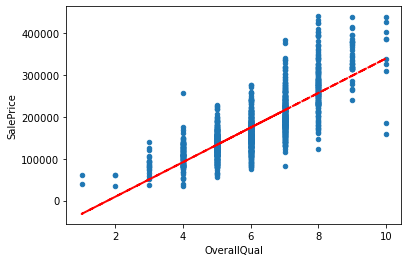

In [9]:
scatter_plot = df.plot(
    kind="scatter", x=max_abs_corr_col, y="SalePrice"
)

scatter_plot.plot(
    x, y_pred,
    "--",
    color="red", 
    linewidth=2
)

9. Encuentra el valor $R^2$ asociada a esta regresión lineal. ¿Qué tan bueno es este modelo? 

In [10]:
r2_score(y, y_pred)

0.6352280375862089